# **Brain-Tumour-Detection**

##**Importing Libraries**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from PIL import Image,ImageEnhance
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten,Dropout,Input
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from sklearn.utils import shuffle

##**Loading the Dataset**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
train_dr = "/content/drive/MyDrive/Brain-Tumor-Dataset/Training"


train_paths =[]
train_labels=[]

for label in os.listdir(train_dr):
  for image in os.listdir(os.path.join(train_dr,label)):
    train_paths.append(os.path.join(train_dr,label,image))
    train_labels.append(label)

train_paths,train_labels = shuffle(train_paths,train_labels)


In [ ]:
# train_paths

In [5]:

test_dr = "/content/drive/MyDrive/Brain-Tumor-Dataset/Testing"

test_paths =[]
test_labels=[]

for label in os.listdir(test_dr):
  for image in os.listdir(os.path.join(test_dr,label)):
    test_paths.append(os.path.join(test_dr,label,image))
    test_labels.append(label)

test_paths,test_labels = shuffle(test_paths,test_labels)


## **Data Visualization**

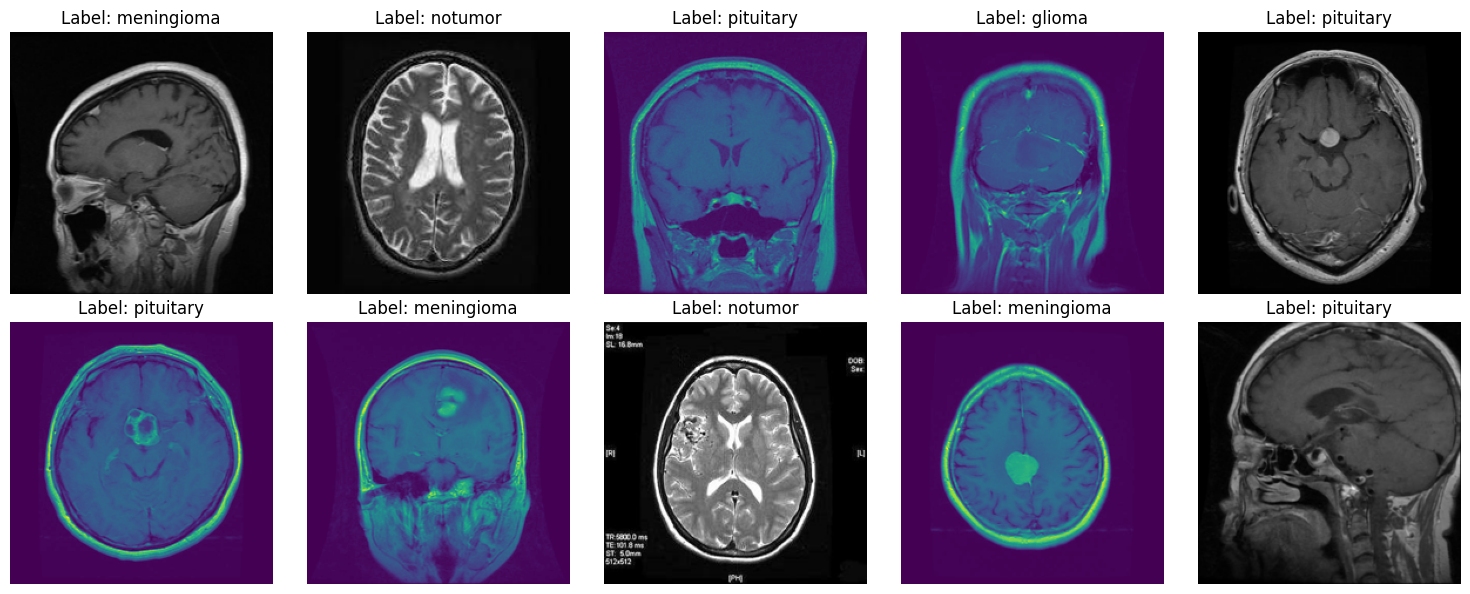

In [ ]:
random_indices = random.sample(range(len(train_paths)), 10)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i, idx in enumerate(random_indices):
    img = Image.open(train_paths[idx]).resize((224, 224))
    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(f"Label: {train_labels[idx]}")
plt.tight_layout()
plt.show()

##**Preprocessing**

In [6]:
import shutil

LOCAL_ROOT = "/content/brain_tumor_data"

if not os.path.exists(LOCAL_ROOT):
    shutil.copytree("/content/drive/MyDrive/Brain-Tumor-Dataset", LOCAL_ROOT)

train_dr = os.path.join(LOCAL_ROOT, "Training")
test_dr = os.path.join(LOCAL_ROOT, "Testing")

In [7]:
img_size = 224

In [8]:
def build_dataset(paths, labels, class_to_idx, img_size=img_size):
    images = []
    for path in paths:
        img = Image.open(path).convert("RGB").resize((img_size, img_size))
        img = np.array(img, dtype=np.float32) / 255.0
        images.append(img)
    x = np.array(images)
    y = np.array([class_to_idx[l] for l in labels])
    return x, y

class_names = sorted(os.listdir(train_dr))
class_to_idx = {name: i for i, name in enumerate(class_names)}
print(class_names)

x_train, y_train = build_dataset(train_paths, train_labels, class_to_idx)
x_test, y_test = build_dataset(test_paths, test_labels, class_to_idx)

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

['glioma', 'meningioma', 'notumor', 'pituitary']
(5616, 224, 224, 3) (5616,)
(1600, 224, 224, 3) (1600,)


In [66]:
import hashlib

def file_hash(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

train_hashes = set(file_hash(p) for p in train_paths)
test_hashes  = set(file_hash(p) for p in test_paths)

overlap = train_hashes & test_hashes

print("Overlapping images:", len(overlap))

Overlapping images: 0


##**Data Augmentation**





In [9]:
def mobilenet_rescale(img):
    return (img * 2) - 1

# MobileNetV2 expects pixels in [-1, 1]
# our arrays are already [0,1]
# so we rescale those pixels



In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# For the baseline CNN -- NO rescale function, data stays [0,1]
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest"
)

# For MobileNetV2 only -- rescales to [-1,1] on the fly, per batch
train_datagen_mnv2 = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest",
    preprocessing_function=mobilenet_rescale
)

In [10]:
from sklearn.model_selection import train_test_split
x_train_fit, x_val, y_train_fit, y_val = train_test_split(
    x_train, y_train,
    stratify=y_train,
    test_size=0.1,
    random_state=42
)

print("Train:", x_train_fit.shape, "Val:", x_val.shape, "Test:", x_test.shape)

del x_train, y_train   # x_train_fit + x_val together already cover this data, CLEARING MEMORY (Colab was crashing)
import gc; gc.collect()

Train: (5054, 224, 224, 3) Val: (562, 224, 224, 3) Test: (1600, 224, 224, 3)


0

In [11]:
num_classes = len(class_names)

In [12]:
batch_size = 32

##**Model**

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten,Conv2D,MaxPooling2D,Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:


model = Sequential([
    Conv2D(32,(3,3),activation="relu",input_shape=(img_size,img_size,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3), activation="relu"),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation="relu"),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128 , activation="relu"),
    Dropout(0.5),
    Dense(num_classes,activation="softmax")

])

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_datagen.flow(x_train_fit,y_train_fit,batch_size=batch_size),
    validation_data=(x_val,y_val),
    epochs=40,
    callbacks=[early_stop]
)

Epoch 1/40
158/158 ━━━━━━━━━━━━━━━━━━━━ 82s 468ms/step - accuracy: 0.4858 - loss: 1.1186 - val_accuracy: 0.7117 - val_loss: 0.7969
Epoch 2/40
158/158 ━━━━━━━━━━━━━━━━━━━━ 66s 420ms/step - accuracy: 0.6387 - loss: 0.8698 - val_accuracy: 0.8132 - val_loss: 0.6165
Epoch 3/40
158/158 ━━━━━━━━━━━━━━━━━━━━ 65s 410ms/step - accuracy: 0.6824 - loss: 0.7969 - val_accuracy: 0.8007 - val_loss: 0.5963
Epoch 4/40
158/158 ━━━━━━━━━━━━━━━━━━━━ 65s 413ms/step - accuracy: 0.7105 - loss: 0.7362 - val_accuracy: 0.7740 - val_loss: 0.5994
Epoch 5/40
158/158 ━━━━━━━━━━━━━━━━━━━━ 64s 404ms/step - accuracy: 0.7331 - loss: 0.6864 - val_accuracy: 0.8007 - val_loss: 0.5529
Epoch 6/40
158/158 ━━━━━━━━━━━━━━━━━━━━ 64s 408ms/step - accuracy: 0.7382 - loss: 0.6675 - val_accuracy: 0.7865 - val_loss: 0.5050
Epoch 7/40
158/158 ━━━━━━━━━━━━━━━━━━━━ 65s 412ms/step - accuracy: 0.7444 - loss: 0.6535 - val_accuracy: 0.7972 - val_loss: 0.5043
Epoch 8/40
158/158 ━━━━━━━━━━━━━━━━━━━━ 63s 399ms/step - accuracy: 0.7535 - loss: 0

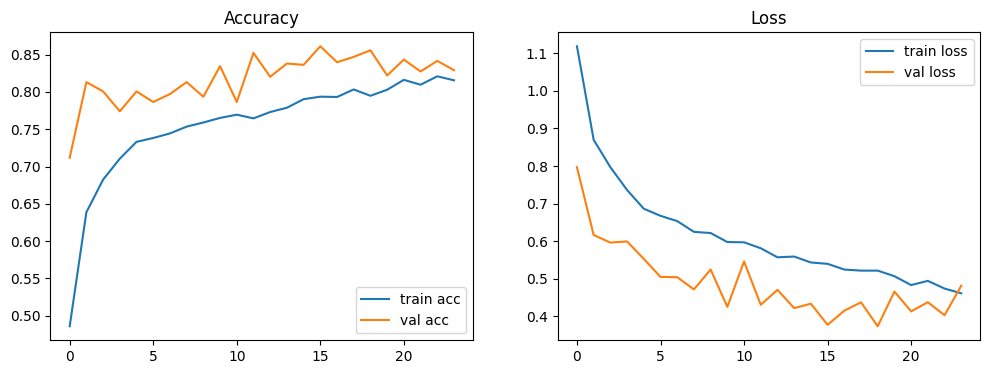

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="train acc")
plt.plot(history.history["val_accuracy"], label="val acc")
plt.legend(); plt.title("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.legend(); plt.title("Loss")

plt.show()

In [ ]:
best_val_loss = np.min(history.history['val_loss'])
best_epoch = np.argmin(history.history['val_loss']) + 1 # +1 because epochs are 1-indexed
best_val_accuracy = history.history['val_accuracy'][best_epoch - 1]

print(f"Best Epoch : {best_epoch}")
print(f"Best Accuracy: {best_val_accuracy * 100} %")
print(f"Best Val Loss: {best_val_loss}")

Best Epoch : 19
Best Accuracy: 85.58719158172607 %
Best Val Loss: 0.37367430329322815


50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7588 - loss: 0.8991
Self-Made Model - Test Accuracy: 75.87500214576721 %
Self-Made Model - Test Loss : 0.8991020917892456
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step

Classfication Report:

              precision    recall  f1-score   support

      glioma       0.84      0.53      0.65       400
  meningioma       0.68      0.54      0.60       400
     notumor       0.72      0.99      0.83       400
   pituitary       0.81      0.98      0.89       400

    accuracy                           0.76      1600
   macro avg       0.76      0.76      0.74      1600
weighted avg       0.76      0.76      0.74      1600



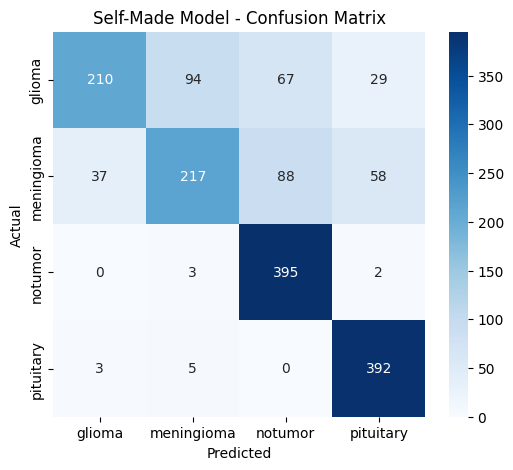

In [ ]:
from sklearn.metrics import classification_report ,confusion_matrix
import seaborn as sns
test_loss,test_acc = model.evaluate(x_test,y_test)

print("Self-Made Model - Test Accuracy:",test_acc*100,"%")
print("Self-Made Model - Test Loss :",test_loss )

y_pred_prob = model.predict(x_test)
y_pred = np.argmax(y_pred_prob,axis=1)

print("\nClassfication Report:\n")
print(classification_report(y_test,y_pred,target_names=class_names))


cm= confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True, fmt="d",xticklabels=class_names,yticklabels=class_names,cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Self-Made Model - Confusion Matrix")
plt.show()

##**MobileNetV2**

In [13]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D,Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(img_size,img_size,3)
)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128,activation="relu")(x)
x = Dropout(0.4)(x)
output = Dense(num_classes,activation="softmax")(x)

mv2_model = Model(inputs = base_model.input,outputs = output)

mv2_model.compile(
    optimizer = Adam(learning_rate=0.0001),
    loss = "sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

mv2_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [14]:

early_stop_mv2  =EarlyStopping(
            monitor="val_loss",
            patience = 5 ,
            restore_best_weights =True
                               )
reduce_lr_mv2 = ReduceLROnPlateau(
            monitor="val_loss",
            factor = 0.5,
            patience = 3 ,
            min_lr = 1e-6
)

mv2_history = mv2_model.fit(
    train_datagen_mnv2.flow(x_train_fit, y_train_fit, batch_size=batch_size),
    validation_data=(mobilenet_rescale(x_val), y_val),
    callbacks=[early_stop_mv2, reduce_lr_mv2],
    epochs=35
)

Epoch 1/35
158/158 ━━━━━━━━━━━━━━━━━━━━ 286s 2s/step - accuracy: 0.6535 - loss: 0.8619 - val_accuracy: 0.7918 - val_loss: 0.5626 - learning_rate: 1.0000e-04
Epoch 2/35
158/158 ━━━━━━━━━━━━━━━━━━━━ 298s 2s/step - accuracy: 0.7986 - loss: 0.5365 - val_accuracy: 0.8274 - val_loss: 0.4719 - learning_rate: 1.0000e-04
Epoch 3/35
158/158 ━━━━━━━━━━━━━━━━━━━━ 302s 2s/step - accuracy: 0.8409 - loss: 0.4392 - val_accuracy: 0.8381 - val_loss: 0.4317 - learning_rate: 1.0000e-04
Epoch 4/35
158/158 ━━━━━━━━━━━━━━━━━━━━ 299s 2s/step - accuracy: 0.8510 - loss: 0.4073 - val_accuracy: 0.8416 - val_loss: 0.3915 - learning_rate: 1.0000e-04
Epoch 5/35
158/158 ━━━━━━━━━━━━━━━━━━━━ 276s 2s/step - accuracy: 0.8605 - loss: 0.3804 - val_accuracy: 0.8612 - val_loss: 0.3762 - learning_rate: 1.0000e-04
Epoch 6/35
158/158 ━━━━━━━━━━━━━━━━━━━━ 276s 2s/step - accuracy: 0.8744 - loss: 0.3498 - val_accuracy: 0.8577 - val_loss: 0.3572 - learning_rate: 1.0000e-04
Epoch 7/35
158/158 ━━━━━━━━━━━━━━━━━━━━ 293s 2s/step - acc

In [15]:
mv2_model.save("mv2_model.keras")


In [16]:
mv2_model.save("mv2_model.h5")

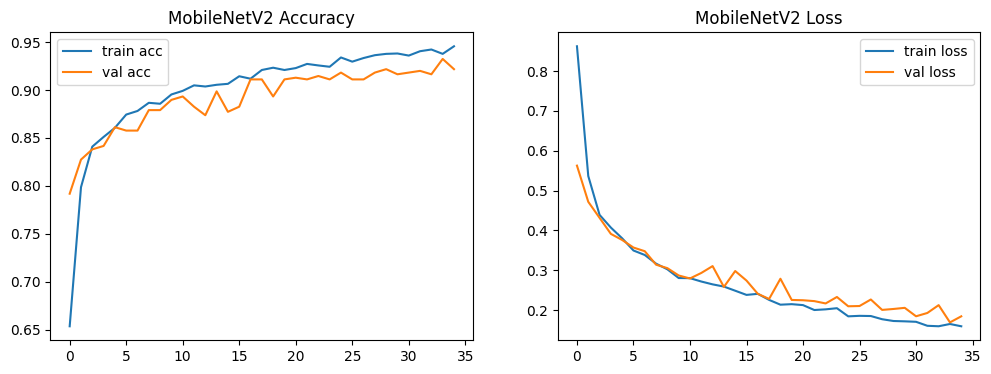

In [17]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(mv2_history.history["accuracy"], label="train acc")
plt.plot(mv2_history.history["val_accuracy"], label="val acc")
plt.legend(); plt.title("MobileNetV2 Accuracy")

plt.subplot(1, 2, 2)
plt.plot(mv2_history.history["loss"], label="train loss")
plt.plot(mv2_history.history["val_loss"], label="val loss")
plt.legend(); plt.title("MobileNetV2 Loss")

plt.show()

50/50 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.8813 - loss: 0.4247
 Base MobileNetV2 Model- Test Accuracy: 88.12500238418579 %
Base MobileNetV2  Model - Test Loss : 0.4246690273284912
50/50 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step

Classfication Report:

              precision    recall  f1-score   support

      glioma       0.96      0.69      0.80       400
  meningioma       0.76      0.86      0.81       400
     notumor       0.91      0.99      0.95       400
   pituitary       0.92      0.98      0.95       400

    accuracy                           0.88      1600
   macro avg       0.89      0.88      0.88      1600
weighted avg       0.89      0.88      0.88      1600



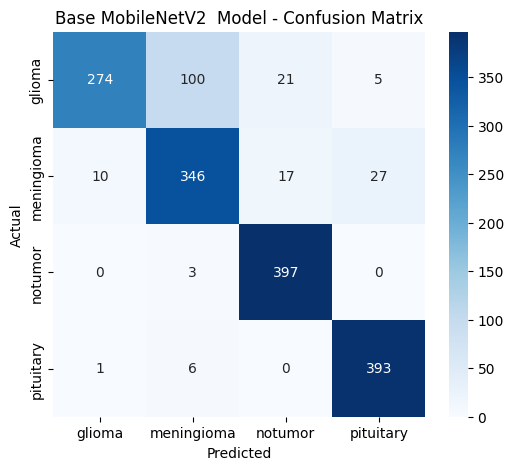

In [18]:
from sklearn.metrics import classification_report ,confusion_matrix
import seaborn as sns
test_loss, test_acc = mv2_model.evaluate(mobilenet_rescale(x_test), y_test)


print(" Base MobileNetV2 Model- Test Accuracy:",test_acc*100,"%")
print("Base MobileNetV2  Model - Test Loss :",test_loss )

y_pred_prob = mv2_model.predict(mobilenet_rescale(x_test))
y_pred = np.argmax(y_pred_prob,axis=1)

print("\nClassfication Report:\n")
print(classification_report(y_test,y_pred,target_names=class_names))


cm= confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True, fmt="d",xticklabels=class_names,yticklabels=class_names,cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Base MobileNetV2  Model - Confusion Matrix")
plt.show()

##**Fine-Tuning**

In [ ]:
base_model.trainable = True

fine_tune_at =  len(base_model.layers)  - 15

for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

print("Trainable Layers :",sum(l.trainable for l in base_model.layers))

Trainable Layers : 15


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D,Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(img_size,img_size,3)
)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128,activation="relu")(x)
x = Dropout(0.4)(x)
output = Dense(num_classes,activation="softmax")(x)

mv2_model = Model(inputs = base_model.input,outputs = output)

mv2_model.compile(
    optimizer = Adam(learning_rate=0.0001),
    loss = "sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

mv2_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
mv2_model.compile(
    optimizer =Adam(learning_rate=0.00001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
early_stop_tuned = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights= True
)

reduce_lr_tuned = ReduceLROnPlateau(
    monitor="val_loss",
    patience =3,
    restore_best_weights=True,
    min_lr=1e-8,
    factor = 0.5
)

# Pre-rescale the validation data to avoid graph tracer signature errors
# x_val_rescaled = mobilenet_rescale(x_val)

tuned_history = mv2_model.fit(
    train_datagen_mnv2.flow(x_train_fit, y_train_fit, batch_size=batch_size),
    validation_data=(mobilenet_rescale(x_val), y_val),
    callbacks=[early_stop_tuned, reduce_lr_tuned],
    epochs=25
)

Epoch 1/25
158/158 ━━━━━━━━━━━━━━━━━━━━ 339s 2s/step - accuracy: 0.2825 - loss: 1.8074 - val_accuracy: 0.3897 - val_loss: 1.3018 - learning_rate: 1.0000e-05
Epoch 2/25
158/158 ━━━━━━━━━━━━━━━━━━━━ 313s 2s/step - accuracy: 0.3789 - loss: 1.4135 - val_accuracy: 0.5552 - val_loss: 1.0605 - learning_rate: 1.0000e-05
Epoch 3/25
158/158 ━━━━━━━━━━━━━━━━━━━━ 331s 2s/step - accuracy: 0.4911 - loss: 1.1771 - val_accuracy: 0.6655 - val_loss: 0.9069 - learning_rate: 1.0000e-05
Epoch 4/25
158/158 ━━━━━━━━━━━━━━━━━━━━ 316s 2s/step - accuracy: 0.5809 - loss: 1.0187 - val_accuracy: 0.7171 - val_loss: 0.8016 - learning_rate: 1.0000e-05
Epoch 5/25
158/158 ━━━━━━━━━━━━━━━━━━━━ 309s 2s/step - accuracy: 0.6294 - loss: 0.9177 - val_accuracy: 0.7580 - val_loss: 0.7191 - learning_rate: 1.0000e-05
Epoch 6/25
158/158 ━━━━━━━━━━━━━━━━━━━━ 324s 2s/step - accuracy: 0.6763 - loss: 0.8300 - val_accuracy: 0.7865 - val_loss: 0.6628 - learning_rate: 1.0000e-05
Epoch 7/25
158/158 ━━━━━━━━━━━━━━━━━━━━ 304s 2s/step - acc

In [ ]:
mv2_model.save("mv2_tuned_model.keras")


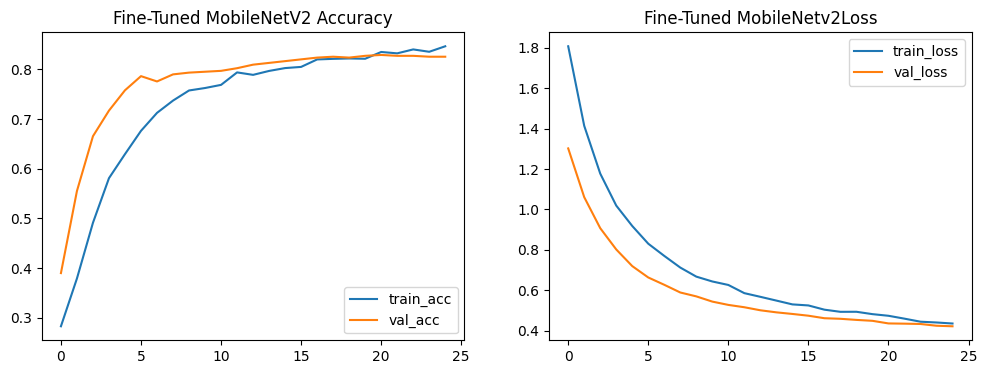

Best Epoch : 25
Best Val Accuracy: 82.91814923286438 %
Best Val Loss : 0.4212714433670044


In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(tuned_history.history["accuracy"],label="train_acc")
plt.plot(tuned_history.history["val_accuracy"],label="val_acc")
plt.legend();
plt.title("Fine-Tuned MobileNetV2 Accuracy")

plt.subplot(1,2,2)
plt.plot(tuned_history.history["loss"],label="train_loss")
plt.plot(tuned_history.history["val_loss"],label="val_loss")
plt.legend();
plt.title("Fine-Tuned MobileNetv2Loss")

plt.show()


best_epoch = tuned_history.history["val_loss"].index(min(tuned_history.history["val_loss"])) + 1
print("Best Epoch :", best_epoch)
print("Best Val Accuracy:", max(tuned_history.history["val_accuracy"]) * 100, "%")
print("Best Val Loss :", min(tuned_history.history["val_loss"]))

50/50 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.7900 - loss: 0.5938
Fine Tuned MobileNetV2 - Test Accuracy: 79.00000214576721 %
Fine Tuned MobileNetV2 - Test Loss : 0.5937699675559998
50/50 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step

Classification Report:

              precision    recall  f1-score   support

      glioma       0.89      0.63      0.74       400
  meningioma       0.72      0.57      0.64       400
     notumor       0.80      0.98      0.88       400
   pituitary       0.77      0.98      0.86       400

    accuracy                           0.79      1600
   macro avg       0.80      0.79      0.78      1600
weighted avg       0.80      0.79      0.78      1600



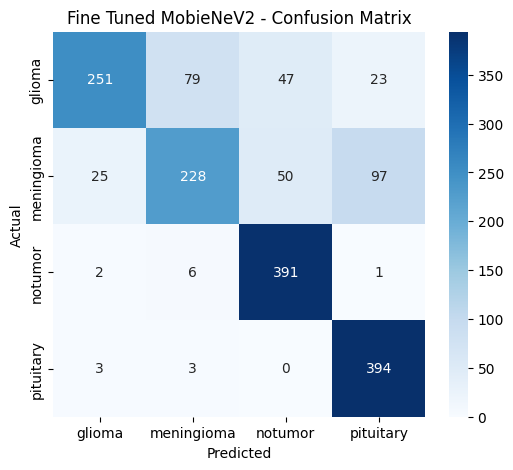

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
test_loss,test_acc = mv2_model.evaluate(mobilenet_rescale(x_test),y_test)

print("Fine Tuned MobileNetV2 - Test Accuracy:",test_acc*100,"%")
print("Fine Tuned MobileNetV2 - Test Loss :",test_loss )

y_pred_prob = mv2_model.predict(mobilenet_rescale(x_test))
y_pred = np.argmax(y_pred_prob,axis=1)

print("\nClassification Report:\n")
print(classification_report(y_test,y_pred,target_names=class_names))

cm = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt="d",xticklabels=class_names,yticklabels=class_names,cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Fine Tuned MobieNeV2 - Confusion Matrix")
plt.show()


##**Comparsion**

In [58]:
import pandas as pd


baseline_val_acc = 85.58719158172607
baseline_val_loss = 0.37367430329322815

mv2_base_val_acc = 93.24
mv2_base_val_loss = 0.1696

mv2_tuned_val_acc = 82.91814923286438
mv2_tuned_val_loss = 0.4212714433670044


baseline_test_acc = 75.87500214576721
baseline_test_loss = 0.8991020917892456

mv2_base_test_acc = 88.12500238418579
mv2_base_test_loss = 0.4246690273284912

mv2_tuned_test_acc = 79.00000214576721
mv2_tuned_test_loss = 0.5937699675559998

comparison_data = {
    "Model": [
        "Self Baseline CNN Model",
        "Base MobileNetV2 (Feature Extractor)",
        "Fine-Tuned MobileNetV2"
    ],
    "Best Val Accuracy (%)": [baseline_val_acc, mv2_base_val_acc, mv2_tuned_val_acc],
    "Best Val Loss": [baseline_val_loss, mv2_base_val_loss, mv2_tuned_val_loss],
    "Test Accuracy (%)": [baseline_test_acc, mv2_base_test_acc, mv2_tuned_test_acc],
    "Test Loss": [baseline_test_loss, mv2_base_test_loss, mv2_tuned_test_loss]
}

df_comparison = pd.DataFrame(comparison_data)
display(df_comparison.style.hide(axis='index')\
       .background_gradient(cmap='Blues', subset=['Best Val Accuracy (%)', 'Test Accuracy (%)']))

Model,Best Val Accuracy (%),Best Val Loss,Test Accuracy (%),Test Loss
Self Baseline CNN Model,85.587192,0.373674,75.875002,0.899102
Base MobileNetV2 (Feature Extractor),93.240000,0.169600,88.125002,0.424669
Fine-Tuned MobileNetV2,82.918149,0.421271,79.000002,0.593770


##**Insights**

In [13]:
mv2_model = tf.keras.models.load_model('/content/mv2_model.keras')

In [62]:
for i, name in enumerate(class_names):
    pencil = y_test == i
    acc = (y_pred[pencil] == y_test[pencil]).mean() * 100
    print(f"{name}: {acc:.2f}% ({pencil.sum()} images)")

glioma: 68.50% (400 images)
meningioma: 86.50% (400 images)
notumor: 99.25% (400 images)
pituitary: 98.25% (400 images)


50/50 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step
Mean Confidence when Correct: 93.838066 %
Mean Confidence when Wrong: 74.11072 %


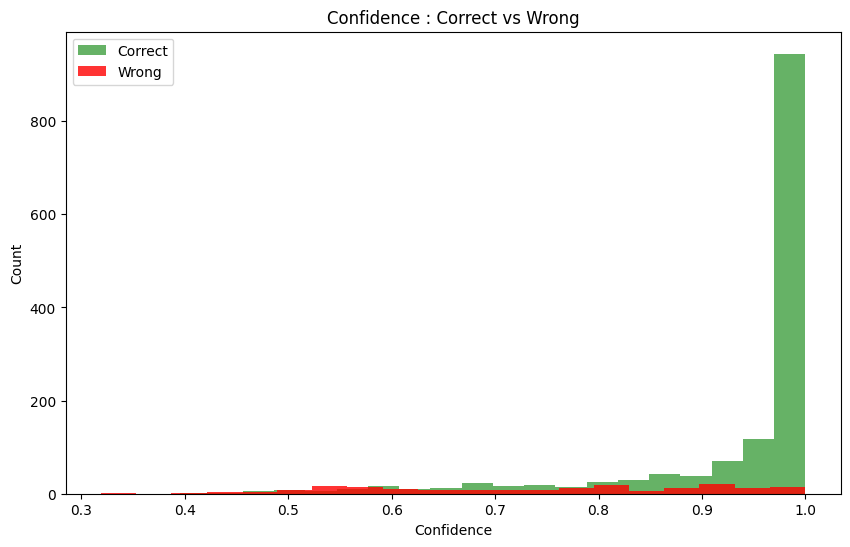

In [27]:
confidences = np.max(mv2_model.predict(mobilenet_rescale(x_test)),axis=1)
correct_conf  = confidences[y_pred == y_test]
wrong_conf = confidences[y_pred != y_test]

print("Mean Confidence when Correct:", correct_conf.mean() * 100, "%")
print("Mean Confidence when Wrong:",wrong_conf.mean() * 100 ,"%")

plt.figure(figsize=(10,6))
plt.hist(correct_conf, bins=20,alpha=0.6,color="green",label="Correct")
plt.hist(wrong_conf,bins=20,alpha=0.8,color="red",label="Wrong")
plt.xlabel("Confidence")
plt.ylabel("Count")
plt.legend()
plt.title("Confidence : Correct vs Wrong")
plt.show()

##**Prediction**

In [46]:
def predict_image(image_path,model,class_names,img_size=224):
  img = Image.open(image_path).convert("RGB").resize((img_size,img_size))
  arr = np.array(img,dtype=np.float32)/255.0
  arr_input = ((arr * 2) - 1)[np.newaxis,...]

  probability = model.predict(arr_input,verbose=0)[0]
  prediction_idx = int(np.argmax(probability))

  return{
      "prediction":class_names[prediction_idx],
      "confidence":float(probability[prediction_idx]),
      "all_probabilities": {name: float(p) for name, p in zip(class_names, probability)}
  }

In [47]:
result = predict_image(test_paths[100], mv2_model,class_names)
print("True Label:", test_labels[100])
print(result)

True Label: glioma
{'prediction': 'glioma', 'confidence': 0.9945998191833496, 'all_probabilities': {'glioma': 0.9945998191833496, 'meningioma': 0.004826205316931009, 'notumor': 5.776701527793193e-06, 'pituitary': 0.0005681536858901381}}


In [60]:
for i in range(5):
    result = predict_image(test_paths[i], mv2_model, class_names)
    status = "Correct" if result["prediction"] == test_labels[i] else "Wrong"
    print(f"[{status}] True: {test_labels[i]:12s} | Predicted: {result['prediction']:12s} | Confidence: {result['confidence']*100:.1f}%")

[Correct] True: meningioma   | Predicted: meningioma   | Confidence: 88.0%
[Correct] True: notumor      | Predicted: notumor      | Confidence: 99.5%
[Correct] True: meningioma   | Predicted: meningioma   | Confidence: 93.4%
[Correct] True: glioma       | Predicted: glioma       | Confidence: 97.8%
[Correct] True: pituitary    | Predicted: pituitary    | Confidence: 99.9%


##**Grad-CAM**

In [26]:
import cv2

last_conv_layer = "Conv_1"

def make_gradcam_heatmap(img_array,model,last_conv_layer_name=last_conv_layer,pred_index=None):
   grad_model = tf.keras.models.Model(
       model.inputs,
       [model.get_layer(last_conv_layer_name).output,model.output]
   )

   with tf.GradientTape() as tape:
     conv_outputs,predictions = grad_model(img_array)
     if pred_index is None:
       pred_index = tf.argmax(predictions[0])
     class_channel = predictions[:, pred_index]

   grads = tape.gradient(class_channel,conv_outputs)

   pooled_grads = tf.reduce_mean(grads,axis=(0,1,2))

   conv_outputs = conv_outputs[0]
   heatmap = conv_outputs @ pooled_grads[...,tf.newaxis]
   heatmap =  tf.squeeze(heatmap)

   heatmap = tf.maximum(heatmap,0) / tf.math.reduce_max(heatmap)
   return heatmap.numpy()

In [25]:
def overlay_gradcam(img,heatmap,alpha=0.4):
  img_uint8 = np.uint8(img * 255)

  heatmap = cv2.resize(heatmap,(img.shape[1],img.shape[0]))
  heatmap = np.uint8(255 * heatmap)
  heatmap_color = cv2.applyColorMap(heatmap,cv2.COLORMAP_JET)
  heatmap_color = cv2.cvtColor(heatmap_color,cv2.COLOR_BGR2RGB)

  overlayed = cv2.addWeighted(img_uint8,1 -alpha, heatmap_color,alpha,0)
  return overlayed

50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step


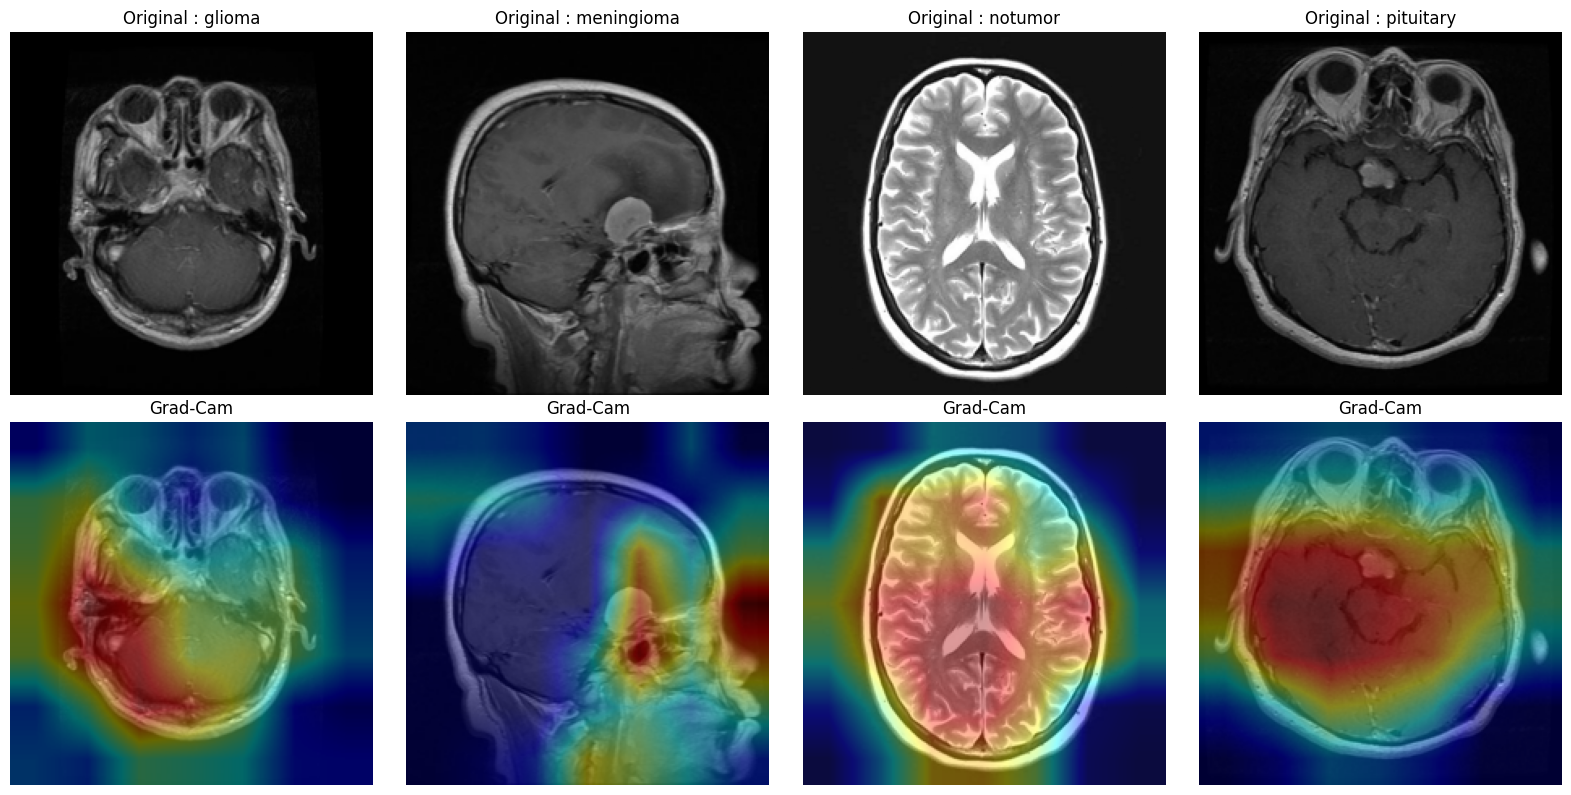

In [29]:
y_pred_prob = mv2_model.predict(mobilenet_rescale(x_test))
y_pred = np.argmax(y_pred_prob, axis=1)

fig ,axes = plt.subplots(2,4, figsize=(16,8))

for i , class_name in enumerate(class_names):
     idx =  np.where((y_test == i) & (y_pred == y_test))[0][0]
     img = x_test[idx]
     img_input = mobilenet_rescale(img)[np.newaxis,...]

     heatmap = make_gradcam_heatmap(img_input,mv2_model)
     overlayed = overlay_gradcam(img,heatmap)

     axes[0,i].imshow(img)
     axes[0,i].set_title(f"Original : {class_name}")
     axes[0,i].axis("off")

     axes[1,i].imshow(overlayed)
     axes[1,i].set_title("Grad-Cam")
     axes[1,i].axis("off")


plt.tight_layout()
plt.show()

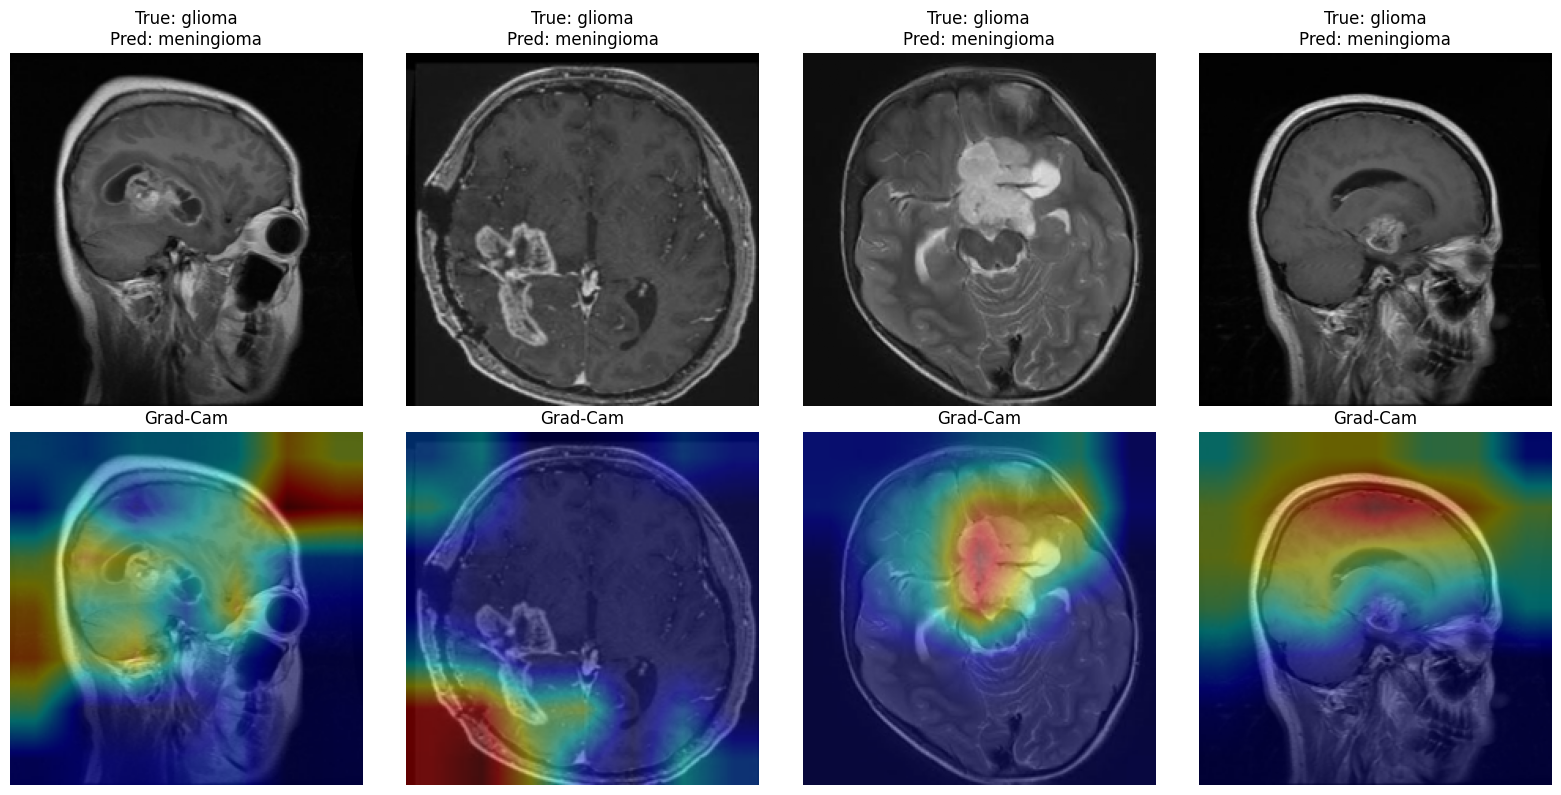

In [33]:
glioma_errors = np.where((y_test == class_to_idx["glioma"]) & (y_pred != y_test))[0][:4]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i , idx in enumerate(glioma_errors):

   img = x_test[idx]
   img_input = mobilenet_rescale(img)[np.newaxis,...]

   true_label = class_names[y_test[idx]]
   pred_label = class_names[y_pred[idx]]

   heatmap = make_gradcam_heatmap(img_input,mv2_model)
   overlayed = overlay_gradcam(img,heatmap)

   axes[0,i].imshow(img)
   axes[0, i].set_title(f"True: {true_label}\nPred: {pred_label}")
   axes[0,i].axis("off")

   axes[1,i].imshow(overlayed)
   axes[1,i].set_title("Grad-Cam")
   axes[1,i].axis("off")


plt.tight_layout()
plt.show()

###Metadata

In [64]:
import json
import os

SAVE_DIR = "/content/drive/MyDrive/brain_tumor_model"
os.makedirs(SAVE_DIR, exist_ok=True)

mv2_model = tf.keras.models.load_model('/content/mv2_model .keras')

mv2_model.save(f"{SAVE_DIR}/brain_tumor_mnv2.keras")


metadata = {
    "model": "MobileNetV2 (frozen base, feature extractor)",
    "img_size": img_size,
    "class_names": class_names,
    "preprocessing": "resize to 224x224, RGB, /255.0, then (x*2)-1",

    "model_comparison": {
        "baseline_cnn_scratch": {
            "best_val_accuracy": 85.587192,
            "best_val_loss": 0.373674,
            "test_accuracy": 75.875002,
            "test_loss": 0.899102
        },
        "mobilenetv2_frozen_base": {
            "best_val_accuracy": 93.240000,
            "best_val_loss": 0.169600,
            "test_accuracy": 88.125002,
            "test_loss": 0.424669
        },
        "mobilenetv2_fine_tuned": {
            "best_val_accuracy": 82.918149,
            "best_val_loss": 0.421271,
            "test_accuracy": 79.000002,
            "test_loss": 0.593770
        }
    },

    "final_model_choice": "mobilenetv2_frozen_base",
    "final_model_reason": "Best performance on both validation and test sets. Fine-tuning decreased accuracy compared to the frozen MobileNetV2 base." ,

    "test_accuracy": 88.125002,
    "test_loss": 0.424669,


    "per_class_accuracy": {
        "glioma": 68.50,
        "meningioma": 86.50,
        "notumor": 99.25,
        "pituitary": 98.25
    },
    "mean_confidence_correct": 93.84,
    "mean_confidence_wrong": 74.11
}

with open(f"{SAVE_DIR}/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved to:", SAVE_DIR)
print("Model size (MB):", os.path.getsize(f"{SAVE_DIR}/brain_tumor_mnv2.keras") / 1e6)

Saved to: /content/drive/MyDrive/brain_tumor_model
Model size (MB): 11.58826
